In [101]:
import pandas as pd
import numpy as np

In [102]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [103]:
df = pd.read_csv("train.csv" , usecols =['Age','Fare','Survived'])

In [104]:
df.dropna(inplace = True) #droped the null value

In [105]:
df.shape

(714, 3)

In [106]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [107]:
x = df.iloc[ :,1:]
y = df.iloc[ : ,0]

In [108]:
x_train ,x_test,y_train ,y_test = train_test_split(x,y,test_size=0.2,
                                                   random_state=42)

In [109]:
x_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [110]:
clf = DecisionTreeClassifier()

In [111]:
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)


In [112]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [113]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6303208137715179

<h3>Now we are going to do binning</h3>

In [115]:
kbin_age = KBinsDiscretizer(n_bins=15 ,encode ='ordinal',strategy='quantile',
                           quantile_method='averaged_inverted_cdf')
kbin_fare = KBinsDiscretizer(n_bins=15 ,encode ='ordinal',strategy='quantile',
                            quantile_method='averaged_inverted_cdf')

In [116]:
trf = ColumnTransformer([('first' ,kbin_age,[0]),
                         ('second',kbin_fare,[1])])

In [117]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.fit_transform(x_test)

In [118]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15,
                  quantile_method='averaged_inverted_cdf'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15,
                  quantile_method='averaged_inverted_cdf')}

In [119]:
trf.named_transformers_['first']

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.",15
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'quantile'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""linear""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7",'averaged_inverted_cdf'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary `... versionadded:: 1.1",None


In [120]:
trf.named_transformers_['first'].n_bins_

array([15])

In [121]:
trf.named_transformers_['first'].bin_edges_

array([array([ 1.,  9., 16., 17., 20., 21., 24., 26., 28., 30., 34., 36., 39.,
              44., 52., 62.])                                                 ],
      dtype=object)

In [122]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [123]:
output['age_labels'] = pd.cut(x=x_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=x_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [124]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
655,24.0,5.0,73.5000,12.0,"(21.0, 24.0]","(53.1, 79.65]"
799,30.0,8.0,24.1500,8.0,"(28.0, 30.0]","(22.525, 26.388]"
734,23.0,5.0,13.0000,6.0,"(21.0, 24.0]","(10.5, 13.0]"
625,61.0,14.0,32.3208,11.0,"(52.0, 62.0]","(31.275, 39.0]"
624,21.0,4.0,16.1000,7.0,"(20.0, 21.0]","(13.0, 17.8]"


In [125]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2 = clf.predict(x_test_trf)

In [152]:
accuracy_score(y_test,y_pred2)

0.6573426573426573

In [156]:
x_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6331181533646322

In [160]:
#
#
#
#
#

In [172]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy,
                                quantile_method='averaged_inverted_cdf')
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy,
                                quantile_method='averaged_inverted_cdf')
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6303012519561814


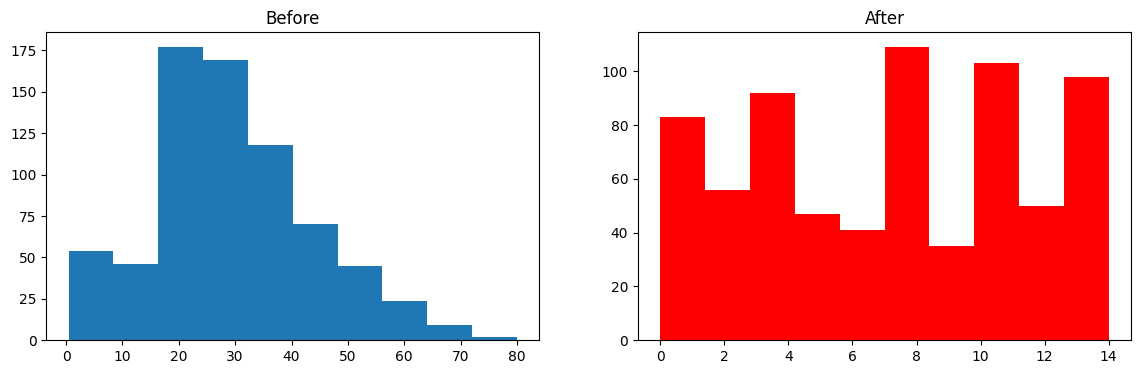

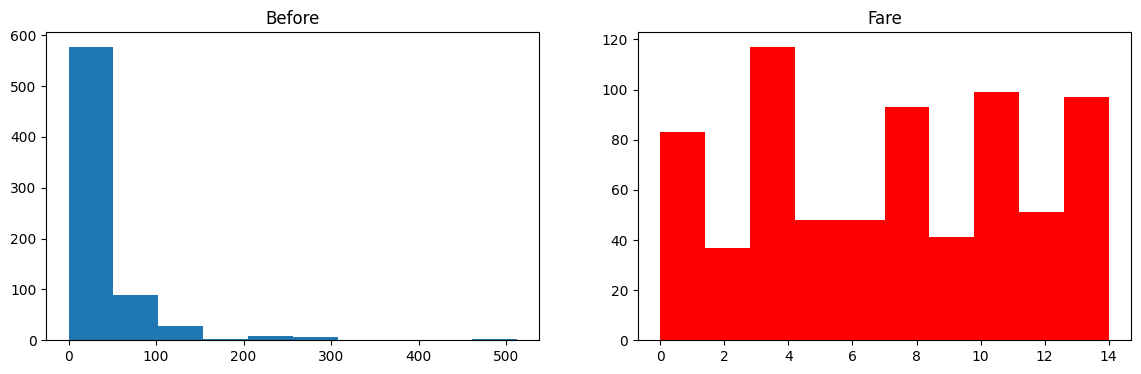

In [182]:
discretize(15,'quantile')

0.6386737089201877


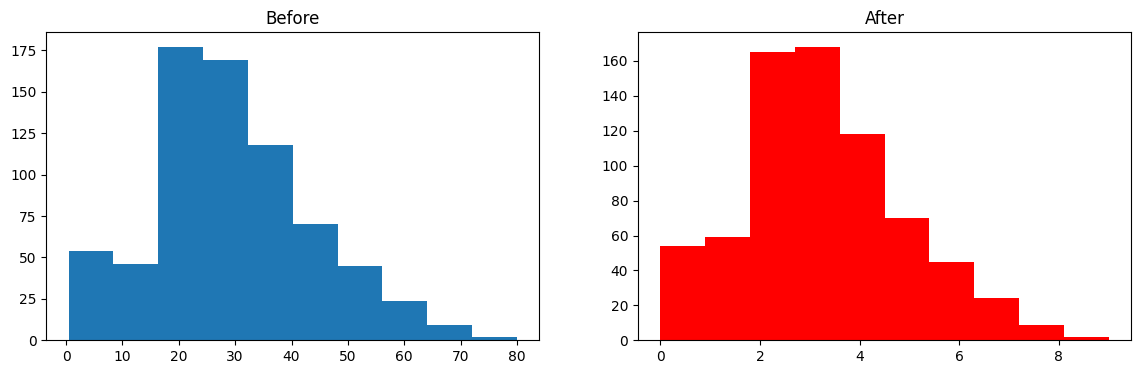

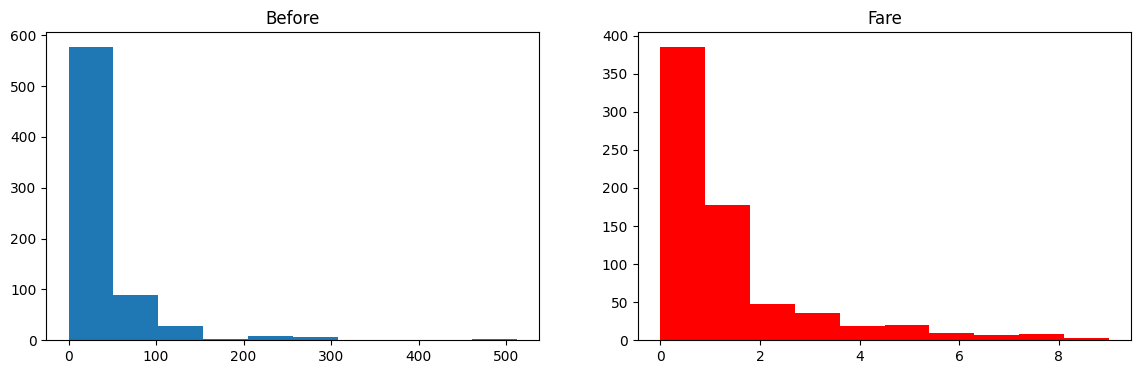

In [186]:
discretize(10,'kmeans')

0.6345070422535211


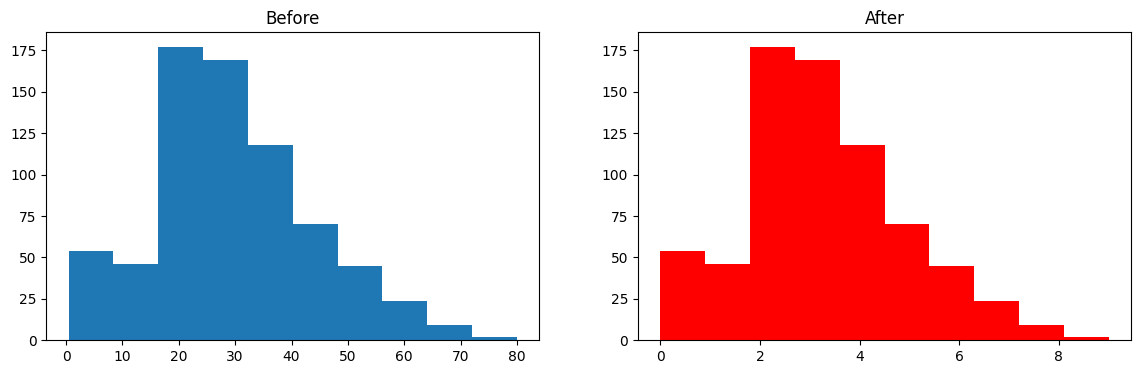

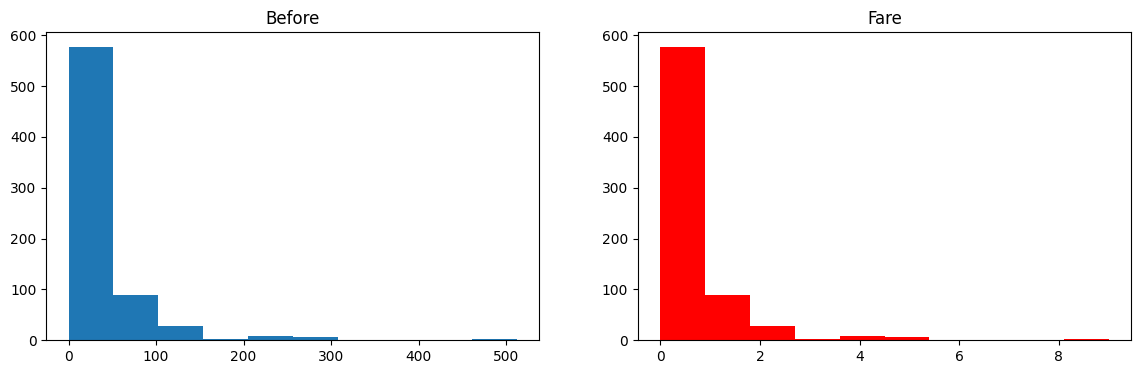

In [188]:
discretize(10,'uniform')